*Note: run train_test_val_split.ipynb before running this notebook*

In [1]:
import pandas as pd
import numpy as np
import igraph as ig
from tqdm import tqdm
from collections import defaultdict
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score, classification_report
)


## Graph helper functions
In order to assign centrality scores for each time window, we construct helper functions to
1. Aggregate multiple transactions (grouped by the u-v pair) into one edge, with the number of transactions and the total transacted value as edge features
2. Compute node centralities for BOTH u and v, for now we only include degree centrality, any additional measures can be added in (betweenness left out due to computational cost)
3. Split data into "blocks" of time, in which the network graph is built solely with data prior to it. This is to prevent data leakage, ensuring that information from future transactions does not influence feature computation for past events. block_size defines the number of hours within one block of time, window_size defines the number of hours prior to the block of time which is considered within the network.


In [2]:
def build_edgelist(edgelist: pd.DataFrame) -> pd.DataFrame:
    if edgelist.empty:
        return pd.DataFrame(columns=["u","v","w_amount","w_count"])
    agg = (edgelist
           .groupby(["u","v"])
           .agg(w_amount=("amount","sum"),
                w_count =("amount","size"))
           .reset_index())
    return agg

In [3]:
def compute_centralities(agg: pd.DataFrame) -> dict:
    if agg.empty:
        return {
            "pr": defaultdict(float), # PageRank weighted by amount
            "outdeg_amt": defaultdict(float),
            "indeg_amt": defaultdict(float),
            "outdeg_cnt": defaultdict(float),
            "indeg_cnt": defaultdict(float),
        }

    # --- build igraph ---
    nodes = pd.Index(pd.concat([agg["u"], agg["v"]]).unique())
    node_to_idx = {n: i for i, n in enumerate(nodes)}

    g = ig.Graph(directed=True)
    g.add_vertices(len(nodes))
    g.vs["name"] = list(nodes)
    edges_idx = list(zip(agg["u"].map(node_to_idx),
                         agg["v"].map(node_to_idx)))
    g.add_edges(edges_idx)

    g.es["w_amount"] = agg["w_amount"].astype(float).tolist()
    g.es["w_count"]  = agg["w_count"].astype(float).tolist()

    # --- centralities ---
    pr = g.pagerank(weights="w_amount")
    outdeg_amt = g.strength(mode="OUT", weights="w_amount")
    indeg_amt  = g.strength(mode="IN",  weights="w_amount")
    outdeg_cnt = g.strength(mode="OUT", weights="w_count")
    indeg_cnt  = g.strength(mode="IN",  weights="w_count")

    names = g.vs["name"]
    return {
        "pr": dict(zip(names, pr)),
        "outdeg_amt": dict(zip(names, outdeg_amt)),
        "indeg_amt":  dict(zip(names, indeg_amt)),
        "outdeg_cnt": dict(zip(names, outdeg_cnt)),
        "indeg_cnt":  dict(zip(names, indeg_cnt)),
    }

In [4]:
def rolling_features(
        df: pd.DataFrame,
        block_size: int = 10,
        window_size: int = 50
    ) -> pd.DataFrame:
    # e.g. For each block of 10 time steps, use the previous 50 time steps of transactions to compute graph features.

    df = df.copy()
    df = df.sort_values("step").reset_index(drop=True)
    df = df.rename(columns={"nameOrig": "u", "nameDest": "v"})
    df["pair_key"] = df["u"] + "→" + df["v"]
    df["block"] = (df["step"] // block_size).astype(int)

    # placeholder columns
    for col in [
        "sender_pr","receiver_pr",
        "sender_outdeg_amt","sender_indeg_amt",
        "receiver_outdeg_amt","receiver_indeg_amt",
        "sender_outdeg_cnt","sender_indeg_cnt",
        "receiver_outdeg_cnt","receiver_indeg_cnt",
        "pagerank_diff","outdeg_amt_diff","indeg_amt_diff",
        "outdeg_cnt_diff","indeg_cnt_diff"
    ]:
        df[col] = 0.0

    for b in tqdm(sorted(df["block"].unique()), desc="Computing rolling features", leave=False):
        block_mask = df["block"] == b
        block_min_step = int(df.loc[block_mask, "step"].min())
        hist_mask = (df["step"] < block_min_step) & (df["step"] >= block_min_step - window_size)
        hist_edges = df.loc[hist_mask, ["u","v","amount","step"]]
        agg = build_edgelist(hist_edges)
        cent = compute_centralities(agg)

        idx = df.index[block_mask]
        df.loc[idx, "sender_pr"] = df.loc[idx, "u"].map(cent["pr"]).fillna(0.0)
        df.loc[idx, "receiver_pr"] = df.loc[idx, "v"].map(cent["pr"]).fillna(0.0)

        df.loc[idx, "sender_outdeg_amt"] = df.loc[idx, "u"].map(cent["outdeg_amt"]).fillna(0.0)
        df.loc[idx, "sender_indeg_amt"]  = df.loc[idx, "u"].map(cent["indeg_amt"]).fillna(0.0)
        df.loc[idx, "receiver_outdeg_amt"] = df.loc[idx, "v"].map(cent["outdeg_amt"]).fillna(0.0)
        df.loc[idx, "receiver_indeg_amt"]  = df.loc[idx, "v"].map(cent["indeg_amt"]).fillna(0.0)

        df.loc[idx, "sender_outdeg_cnt"] = df.loc[idx, "u"].map(cent["outdeg_cnt"]).fillna(0.0)
        df.loc[idx, "sender_indeg_cnt"]  = df.loc[idx, "u"].map(cent["indeg_cnt"]).fillna(0.0)
        df.loc[idx, "receiver_outdeg_cnt"] = df.loc[idx, "v"].map(cent["outdeg_cnt"]).fillna(0.0)
        df.loc[idx, "receiver_indeg_cnt"]  = df.loc[idx, "v"].map(cent["indeg_cnt"]).fillna(0.0)

        df.loc[idx, "pagerank_diff"]  = df.loc[idx, "sender_pr"] - df.loc[idx, "receiver_pr"]
        df.loc[idx, "outdeg_amt_diff"] = df.loc[idx, "sender_outdeg_amt"] - df.loc[idx, "receiver_outdeg_amt"]
        df.loc[idx, "indeg_amt_diff"]  = df.loc[idx, "sender_indeg_amt"]  - df.loc[idx, "receiver_indeg_amt"]
        df.loc[idx, "outdeg_cnt_diff"] = df.loc[idx, "sender_outdeg_cnt"] - df.loc[idx, "receiver_outdeg_cnt"]
        df.loc[idx, "indeg_cnt_diff"]  = df.loc[idx, "sender_indeg_cnt"]  - df.loc[idx, "receiver_indeg_cnt"]

    return df

## Preparation of train/val/test data

Full dataset consists 31 days of data, with about 3 days of data in val and test. We arbitrarily set block_size to 12 and window_size to 48.



In [5]:
df_train = pd.read_csv('../data/FEwithMerchants/FE_train_with_merchants.csv')
df_val = pd.read_csv('../data/FEwithMerchants/FE_validation_with_merchants.csv')
df_test = pd.read_csv('../data/FEwithMerchants/FE_test_with_merchants.csv')

print("Converting categorical columns ...")
categorical_cols = [
    'type', 'hourOfDay', 'dayOfWeek', 'transaction_sequence'
]

for col in categorical_cols:
    # Combine categories from both train, val and test, to avoid unseen categories during inference
    combined_cats = pd.Series(
        pd.concat([df_train[col], df_val[col], df_test[col]], axis=0).dropna().unique()
    )
    categories = sorted(combined_cats.unique())

    df_train[col] = pd.Categorical(df_train[col], categories=categories)
    df_val[col]   = pd.Categorical(df_val[col], categories=categories)
    df_test[col]  = pd.Categorical(df_test[col], categories=categories)

KeyboardInterrupt: 

In [ ]:
selected_features = [
    # transaction-level features
    'step', 'type', 'day', 'hourOfDay', 'dayOfWeek', 'amountLog', 
    # 'amount',         
                
    # account-level features
    'totalSent', 'meanSent', 'stdSent', 'numSent', 
    'totalReceived', 'meanReceived', 'stdReceived', 'numReceived', 'maxAmountReceived', 
    'stdAmountReceived', 'avgAmountToDest', 'std_to_mean_ratio', 
    'pctForwarded24h',

    # transaction pattern features
    'transactionRecency', 'is_early_transaction', 'transaction_sequence', 'sequence_frequency', 'sequence_count',
    'is_transfer_cashout', 'is_cashin_transfer', 'is_cashout_transfer', 'is_cashin_transfer_cashout',
    'is_transfer_transfer', 'is_first_transfer', 'is_cashin_cashout', 

    # aggregated risk signals
    'typeHighValueFlag', 

    # centrality features
    "sender_pr","receiver_pr", 
    "sender_outdeg_amt","sender_indeg_amt", "receiver_outdeg_amt","receiver_indeg_amt",
    "sender_outdeg_cnt","sender_indeg_cnt", "receiver_outdeg_cnt","receiver_indeg_cnt",
    "pagerank_diff","outdeg_amt_diff","indeg_amt_diff", "outdeg_cnt_diff","indeg_cnt_diff",

    # data leakage?
    # 'sender_has_fraud', 'receiver_has_fraud', 'fraudRatioAmongReceivers', 'fraudRatioAmongSenders', 'cumulative_fraud_rate', 'cumulative_frauds', 'cumulative_total'

    # covered by transaction_sequence
    # 'prev_type_1', 'prev_type_2', 'prev_type_3', 'prev_type_4', 'prev_type_5', 
    # 'prev_type_1_encoded', 'prev_type_2_encoded', 'prev_type_3_encoded', 'prev_type_4_encoded', 'prev_type_5_encoded',

    # idk what these are 
    # 'fraction_CASH_IN', 'fraction_CASH_OUT', 'fraction_DEBIT', 'fraction_PAYMENT', 'fraction_TRANSFER',
    # 'fraction_CASH_IN_recv', 'fraction_CASH_OUT_recv', 'fraction_DEBIT_recv', 'fraction_PAYMENT_recv', 'fraction_TRANSFER_recv'
    # 'amountTypeRatio', 
]

In [ ]:
print("Processing training set ...")
df_train = rolling_features(df_train, block_size=12, window_size=48)
Xtrain, ytrain = df_train[selected_features].copy(), df_train["isFraud"].astype(int)

print("Processing validation set ...")
df_val = rolling_features(df_val, block_size=12, window_size=48)
Xval, yval = df_val[selected_features].copy(), df_val["isFraud"].astype(int)

print("Processing test set ...")
df_test = rolling_features(df_test, block_size=12, window_size=48)
Xtest, ytest = df_test[selected_features].copy(), df_test["isFraud"].astype(int)

print("Done!")

Processing training set ...


Computing rolling features:  62%|██████▏   | 16/26 [01:16<01:07,  6.75s/it]

## XGBoost Classifier
- Use RandomSearchCV to tune the hyperparameters, evaluating with validation set
- Evaluate with test Set

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.005, 0.01, 0.05],
    'n_estimators': [50, 100, 300, 600],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.05, 0.1, 0.5, 1],
    'reg_lambda': [0.5, 1, 2],
}

n_iter = 20
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))
results = []

for params in tqdm(param_list, desc="Random Search Hyperparameter Tuning"):
    model = XGBClassifier(
        **params,
        scale_pos_weight=(len(ytrain) - sum(ytrain)) / sum(ytrain),
        random_state=42,
        enable_categorical=True,
        eval_metric="pr_auc",
        n_jobs=-1
    )

    # Evaluate on validation set 
    model.fit(Xtrain, ytrain, eval_set=[(Xval, yval)], verbose=False)

    yval_pred = model.predict_proba(Xval)[:, 1]
    auc = roc_auc_score(yval, yval_pred)
    pr_auc = average_precision_score(yval, yval_pred)

    results.append({
        **params,
        "auc": auc,
        "pr_auc": pr_auc,
    })

df_results = pd.DataFrame(results).sort_values("auc", ascending=False)
print(df_results.head(5))

Random Search Hyperparameter Tuning: 100%|██████████| 20/20 [39:34<00:00, 118.71s/it]

    subsample  reg_lambda  reg_alpha  n_estimators  min_child_weight  \
4         0.8         0.5       1.00           600                 3   
19        0.8         1.0       0.05           600                 3   
15        1.0         0.5       0.50           100                 5   
0         1.0         1.0       0.10           300                10   
7         1.0         1.0       0.00           300                 3   

    max_depth  learning_rate  gamma  colsample_bytree       auc    pr_auc  
4           5           0.01    0.5               0.8  0.963820  0.335797  
19          5           0.01    0.0               0.8  0.963730  0.340978  
15          5           0.05    1.0               1.0  0.963318  0.369669  
0           3           0.05    0.5               0.6  0.961573  0.295252  
7           5           0.05    0.5               0.6  0.961480  0.334623  


In [ ]:
# Best model from Randomized Search
best_model_info = df_results.iloc[0]
best_model_info = best_model_info.to_dict()
best_model_info = {k: int(v) if isinstance(v, float) and v.is_integer() else v
               for k, v in best_model_info.items()}

print("=== Best model hyperparameters from Random Search Hyperparameter Tuning ===")
for k, v in best_model_info.items():
    print(f"{k:<20}: {v}")

# remove metrics from best_model_info to get only parameters
best_model_info.pop("auc", None)
best_model_info.pop("pr_auc", None)
best_params = best_model_info

=== Best model hyperparameters from Random Search Hyperparameter Tuning ===
subsample           : 0.8
reg_lambda          : 0.5
reg_alpha           : 1
n_estimators        : 600
min_child_weight    : 3
max_depth           : 5
learning_rate       : 0.01
gamma               : 0.5
colsample_bytree    : 0.8
auc                 : 0.9638202858432279
pr_auc              : 0.33579737771897383


In [ ]:
# early_stopping_values = [10, 50, 100, 200]
# results = []

# for esr in tqdm(early_stopping_values, "Training with different early stopping values"):    
#     model = XGBClassifier(
#         **best_params,  
#         scale_pos_weight=(len(ytrain) - sum(ytrain)) / sum(ytrain),
#         random_state=42,
#         enable_categorical=True,
#         eval_metric="auc",
#         early_stopping_rounds=esr,
#         n_jobs=-1
#     )
    
#     model.fit(
#         Xtrain, ytrain,
#         eval_set=[(Xval, yval)],
#         verbose=False
#     )
    
#     # Predict on validation set
#     yval_pred = model.predict_proba(Xval)[:, 1]
    
#     # Compute metrics
#     val_auc = roc_auc_score(yval, yval_pred)
#     val_pr  = average_precision_score(yval, yval_pred)
    
#     results.append({
#         "early_stopping_rounds": esr,
#         "best_iteration": model.best_iteration,
#         "validation_auc": val_auc,
#         "validation_pr_auc": val_pr,
#     })

# # Convert to DataFrame for easy viewing
# df_esr = pd.DataFrame(results)
# print(df_esr)

# # update best_params with best n_estimators from early stopping
# best_row = df_esr.loc[df_esr["validation_auc"].idxmax()]
# best_iter = int(best_row["best_iteration"])
# best_params["n_estimators"] = best_iter

In [ ]:
Xtrain_full = pd.concat([Xtrain, Xval])
ytrain_full = pd.concat([ytrain, yval])

# Final model using tuned parameters
best_xgb = XGBClassifier(
    **best_params,          
    random_state=42,
    enable_categorical=True,
    n_jobs=-1,
    eval_metric="pr_auc"
)

best_xgb.fit(Xtrain_full, ytrain_full)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'auc'


## Feature Importance

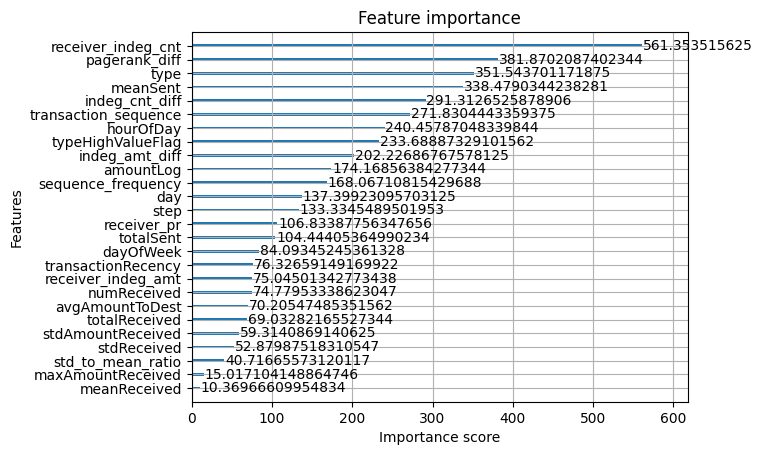

In [ ]:
xgb.plot_importance(best_xgb, importance_type='gain')
plt.show()

Test ROC-AUC: 0.964489699406962
Test PR-AUC : 0.3373038325910162


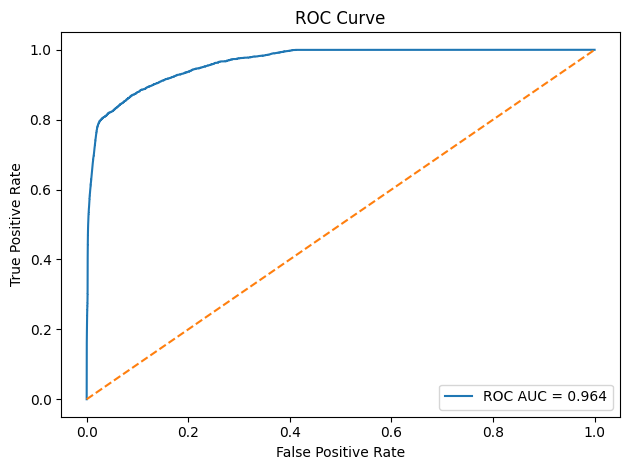

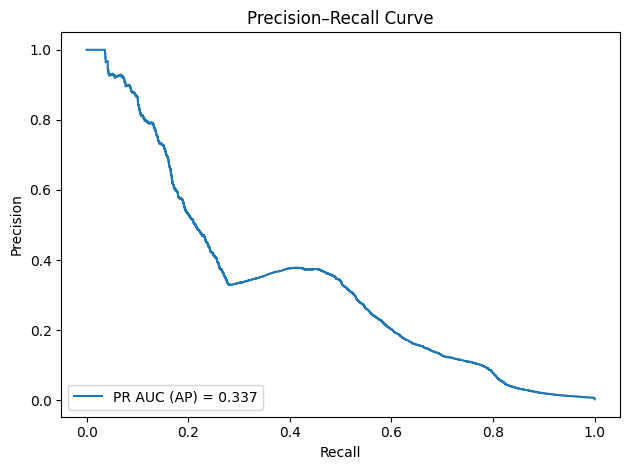

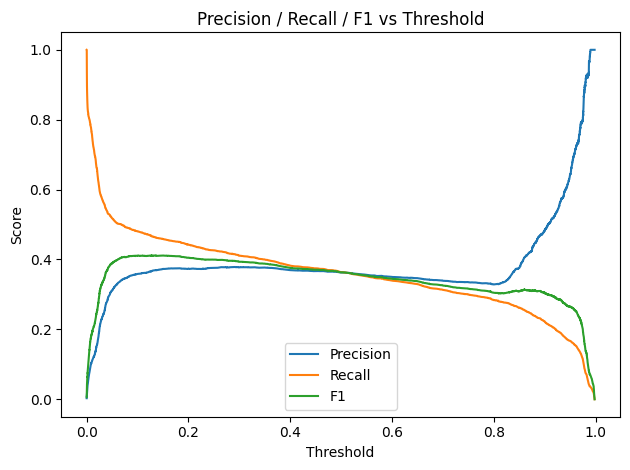

In [ ]:
proba = best_xgb.predict_proba(Xtest)[:,1]
print("Test ROC-AUC:", roc_auc_score(ytest, proba))
print("Test PR-AUC :", average_precision_score(ytest, proba))

y_true = ytest.astype(int)
y_score = proba

fpr, tpr, thr_roc = roc_curve(y_true, y_score)
roc_auc = roc_auc_score(y_true, y_score)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

prec, rec, thr_pr = precision_recall_curve(y_true, y_score)
ap = average_precision_score(y_true, y_score)

plt.figure()
plt.plot(rec, prec, label=f"PR AUC (AP) = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()

thr = np.r_[0.0, thr_pr]  # prepend 0 to align lengths
f1 = 2 * (prec * rec) / np.clip(prec + rec, 1e-12, None)

plt.figure()
plt.plot(thr, prec, label="Precision")
plt.plot(thr, rec,  label="Recall")
plt.plot(thr, f1,   label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 vs Threshold")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# Choose threshold based on business requirements/ PR curve
best_thr = 0.3
print(f"Best F1 Threshold: {best_thr:.4f}")

ytrain_pred = (model.predict_proba(Xtrain)[:,1] >= best_thr).astype(int)
print("Train Classification Report:")
print(classification_report(ytrain, ytrain_pred))

ytest_pred = (proba >= best_thr).astype(int)
print("Test Classification Report:")
print(classification_report(ytest, ytest_pred))


Best F1 Threshold: 0.3000
Train Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93   4132287
           1       0.01      0.96      0.01      3415

    accuracy                           0.86   4135702
   macro avg       0.50      0.91      0.47   4135702
weighted avg       1.00      0.86      0.93   4135702

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1459068
           1       0.38      0.41      0.39      4336

    accuracy                           1.00   1463404
   macro avg       0.69      0.70      0.70   1463404
weighted avg       1.00      1.00      1.00   1463404

